In [84]:
import pandas as pd
import numpy as np
import os
import glob
import PIL.Image as Image
import PIL
import matplotlib.pyplot as plt

In [85]:
import SciServer.CasJobs as CasJobs # query with CasJobs, the primary database for the SDSS
import SciServer.SkyServer as SkyServer # show individual objects through SkyServer
import SciServer.SciDrive

# 1. Acquire data

`PCC.cat` has the ra, dec, label

In [86]:
df0 = pd.read_fwf('../PCC_cat.txt', header=None)


# Bright objects
Unfortunately training the model on incredibly faint images had produced poor results. Our first attempt at rectifying this was choosing the brightest images. Since magnitudes go backwards, we choose a $r < 19.4$ magnitude

In [87]:
brightDF = df0[df0[4] <= 19.4].copy()

brightDF['files'] = (
    "sdss_ra=" + brightDF[2].astype(str) +
    "_dec=" + brightDF[3].astype(str) +
    ".png"
)

brightDF = brightDF.rename(columns={21: "label"})
brightDF

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,label,22,23,24,files
5,NaN,PCC-0006,49.2388,41.4631,19.03,0.00,0.69,0.01,19.28,1.35,...,-0.11,NaN,NaN,NaN,NaN,Likely merging system,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.2388_dec=41.4631.png
6,NaN,PCC-0007,49.2392,41.4215,19.26,0.03,0.97,0.05,20.76,3.79,...,0.68,0.88,0.66,NaN,NaN,Likely background ETG or unresolved source,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.2392_dec=41.4215.png
7,NaN,PCC-0008,49.2411,41.4991,18.51,0.01,1.78,0.02,20.95,2.50,...,0.82,0.93,0.66,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.2411_dec=41.4991.png
10,NaN,PCC-0011,49.2420,41.4454,19.19,0.01,1.51,0.02,21.95,1.02,...,0.59,0.70,0.47,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.242_dec=41.4454.png
25,NaN,PCC-0026,49.2466,41.4451,19.34,0.01,2.04,0.02,21.31,1.20,...,0.85,0.98,0.75,NaN,NaN,Likely cluster or background edge-on disk galaxy,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.2466_dec=41.4451.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5386,NaN,PCC-5387,49.9985,41.3856,18.60,0.01,2.84,0.06,22.78,2.45,...,0.70,0.82,0.65,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.9985_dec=41.3856.png
5407,NaN,PCC-5408,50.0018,41.6806,18.16,0.00,0.16,0.00,15.85,3.30,...,0.12,NaN,NaN,NaN,NaN,Likely background ETG or unresolved source,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=50.0018_dec=41.6806.png
5416,NaN,PCC-5417,50.0028,41.3384,18.84,0.01,1.27,0.02,20.74,2.42,...,0.75,0.78,0.71,NaN,NaN,Likely background ETG or unresolved source,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=50.0028_dec=41.3384.png
5422,NaN,PCC-5423,50.0040,41.3410,17.50,0.01,1.86,0.02,20.45,4.00,...,0.76,0.93,0.69,NaN,NaN,Likely background ETG or unresolved source,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=50.004_dec=41.341.png


In [88]:
L_BG_LTG = "Cluster or background LTG"
BG_ETG = "Likely background ETG or unresolved source"
EDGE_DISK = "Likely cluster or background edge-on disk galaxy"
dE_ETG = "Likely dE/ETGcluster candidate"
MERGING = "Likely merging system"
POSS_dE = "Possible dE/ETGcluster candidate"
WEAK_BG = "background galaxy with possibly weak substructure"
desired = {
    L_BG_LTG: 384,
    BG_ETG: 400,
    EDGE_DISK: 400,
    dE_ETG: None,
    MERGING: None,
    POSS_dE: None,
    WEAK_BG: None,
}

groups = []
for lbl, group in brightDF.groupby("label"):
    n = desired.get(lbl) # type: ignore
    if n is None:
        groups.append(group)
    else:
        k = min(n, len(group))
        groups.append(group.sample(n=k, random_state=42))

downSampleDf0 = pd.concat(groups, ignore_index=True)

# old labels 0,1,2,6 -> new label 0 : background, 
# old labels 3 + 5 -> new label 1 : cluster galaxy
map_to_binary = {
    L_BG_LTG: 0,
    BG_ETG: 0,
    EDGE_DISK: 0,
    WEAK_BG: 0,
    
    dE_ETG: 1,
    POSS_dE: 1,
    MERGING: 1,  # if this belongs with the positives
}

downSampleDf1 = downSampleDf0.assign(
    binary_label = downSampleDf0['label'].map(map_to_binary)
)

# rebalance to equalize classes 0 vs. 1
df0_bin = downSampleDf1[downSampleDf1['binary_label'] == 0]
df1_bin = downSampleDf1[downSampleDf1['binary_label'] == 1]

min_size = min(len(df0_bin), len(df1_bin))

downSampleDf1_balanced = pd.concat([
    df0_bin.sample(n=min_size, random_state=42),
    df1_bin.sample(n=min_size, random_state=42)
]).reset_index(drop=True)

downSampleDf1_balanced


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,label,22,23,24,files,binary_label
0,NaN,PCC-2928,49.6876,41.2260,17.82,0.01,1.87,0.02,20.84,3.10,...,0.27,0.25,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.6876_dec=41.226.png,0
1,NaN,PCC-3408,49.7463,41.6377,19.34,0.00,1.40,0.01,21.93,3.27,...,1.40,0.76,NaN,NaN,Likely background ETG or unresolved source,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.7463_dec=41.6377.png,0
2,NaN,PCC-4969,49.9437,41.3786,18.53,0.00,1.70,0.00,21.37,0.52,...,0.32,0.32,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.9437_dec=41.3786.png,0
3,NaN,PCC-1581,49.5082,41.4069,19.00,0.00,1.41,0.01,21.27,1.63,...,0.89,0.71,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.5082_dec=41.4069.png,0
4,NaN,PCC-0571,49.3431,41.5987,19.09,0.00,1.90,0.01,21.50,1.13,...,1.04,0.78,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.3431_dec=41.5987.png,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,NaN,PCC-5047,49.9523,41.5579,18.07,0.00,5.00,0.03,23.17,1.27,...,NaN,0.28,NaN,NaN,Likely dE/ETGcluster candidate,Unsure,about nucleation,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.9523_dec=41.5579.png,1
248,NaN,PCC-0993,49.4149,41.5612,18.91,0.01,2.95,0.02,23.20,1.26,...,0.63,0.46,NaN,NaN,Likely dE/ETGcluster candidate,Unsure,about nucleation,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.4149_dec=41.5612.png,1
249,NaN,PCC-4551,49.8902,41.5536,17.05,0.00,1.09,0.00,18.99,2.67,...,0.60,0.65,NaN,NaN,Likely dE/ETGcluster candidate,r Brig,t central source,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.8902_dec=41.5536.png,1
250,NaN,PCC-2959,49.6925,41.4049,17.43,0.00,7.62,0.04,23.07,1.78,...,0.64,0.52,NaN,NaN,Likely dE/ETGcluster candidate,Unsure,about nucleation,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.6925_dec=41.4049.png,1


In [89]:
PCC_list = downSampleDf1['files'].to_list()
columnLength = len(PCC_list)
ra_list = [None] * columnLength
dec_list = [None] * columnLength
for i in range(columnLength):
    splitted = PCC_list[i].split('=')
    ra_list[i] = float(splitted[1][:-4])
    dec_list[i] = float(splitted[2][:-4])

downSampleDf1['ra'] = ra_list
downSampleDf1['dec'] = dec_list
downSampleDf1

,0,1,2,3,4,5,6,7,8,9,...,19,20,label,22,23,24,files,binary_label,ra,dec
0,NaN,PCC-2605,49.6469,41.4505,18.42,0.00,1.93,0.01,21.05,3.24,...,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.6469_dec=41.4505.png,0,49.6469,41.4505
1,NaN,PCC-0766,49.3757,41.3132,15.98,0.00,0.26,0.02,21.82,1.58,...,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.3757_dec=41.3132.png,0,49.3757,41.3132
2,NaN,PCC-0168,49.2758,41.5415,17.69,0.00,4.86,0.02,21.93,1.66,...,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.2758_dec=41.5415.png,0,49.2758,41.5415
3,NaN,PCC-0514,49.3329,41.4999,18.53,0.00,1.95,0.00,21.44,0.51,...,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.3329_dec=41.4999.png,0,49.3329,41.4999
4,NaN,PCC-1336,49.4709,41.3465,19.19,0.00,2.22,0.01,22.07,0.80,...,NaN,NaN,Cluster or background LTG,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.4709_dec=41.3465.png,0,49.4709,41.3465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,NaN,PCC-2195,49.6028,41.5367,18.46,0.00,2.24,0.01,21.88,1.99,...,Cluster,or,background galaxy with possibly weak substructure,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.6028_dec=41.5367.png,0,49.6028,41.5367
268,NaN,PCC-2971,49.6947,41.5876,19.33,0.00,0.84,0.00,20.79,1.08,...,Cluster,or,background galaxy with possibly weak substructure,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.6947_dec=41.5876.png,0,49.6947,41.5876
269,NaN,PCC-3286,49.7314,41.5563,18.95,0.00,3.70,0.02,22.71,1.10,...,Cluster,or,background galaxy with possibly weak substructure,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.7314_dec=41.5563.png,0,49.7314,41.5563
270,NaN,PCC-3462,49.7545,41.3027,18.94,0.00,0.70,0.00,19.66,2.14,...,Cluster,or,background galaxy with possibly weak substructure,NaN,NaN,http://dc.zah.uni-heidelberg.de/pcc/q/stamp/dl...,sdss_ra=49.7545_dec=41.3027.png,0,49.7545,41.3027


In [90]:
print(downSampleDf1['binary_label'].value_counts())
print(downSampleDf1_balanced['binary_label'].value_counts())

binary_label
0    146
1    126
Name: count, dtype: int64
binary_label
0    126
1    126
Name: count, dtype: int64


In [91]:
searchDf = pd.read_csv('../Sheets/SpecSearchNoCuts.csv')
searchDf = searchDf.drop_duplicates(subset = 'objID') # sometimes SDSS has some objID duplicates
# pcc_crossDf = pcc_crossDf.drop_duplicates(subset = 'objID')

## Members 0.01 < spec-z < 0.033, else are NonMembers 
specMembers = searchDf['z'].between(0.01, 0.033)
specNonMembers = np.invert(specMembers)

searchDf_specMembers = searchDf.loc[specMembers].copy()
searchDf_specMembers['binary_label'] = np.ones(int(searchDf_specMembers.shape[0]), dtype = int)

searchDf_specNonMembers = searchDf.loc[specNonMembers].copy()
searchDf_specNonMembers['binary_label'] = np.zeros(int(searchDf_specNonMembers.shape[0]), dtype = int)

pcc_nonMembers = downSampleDf1.loc[(downSampleDf1['binary_label'] == 0)]
pcc_Members = downSampleDf1.loc[(downSampleDf1['binary_label'] == 1)]

## sanity checks
print('specbgs:', searchDf_specNonMembers.shape[0])
print('specmems:', searchDf_specMembers.shape[0])
print('total specs', searchDf_specNonMembers.shape[0] + searchDf_specMembers.shape[0])
print(searchDf_specNonMembers.shape[0] + searchDf_specMembers.shape[0] == searchDf.shape[0])

print('pccbgs:', pcc_nonMembers.shape[0])
print('pccmems:', pcc_Members.shape[0])
print('total pccs:', pcc_nonMembers.shape[0] + pcc_Members.shape[0])
print(pcc_nonMembers.shape[0] + pcc_Members.shape[0] == downSampleDf1.shape[0])

print(f'Total: {searchDf_specNonMembers.shape[0] + searchDf_specMembers.shape[0] + pcc_nonMembers.shape[0] + pcc_Members.shape[0]} ')


specbgs: 117
specmems: 116
total specs 233
True
pccbgs: 146
pccmems: 126
total pccs: 272
True
Total: 505 


In [92]:
# pcc_crossDf[['objID', 'ra', 'dec']]
trainObjs = pd.concat([pcc_nonMembers[['ra', 'dec', 'binary_label']],
                      pcc_Members[['ra', 'dec', 'binary_label']],
                      searchDf_specNonMembers[['ra', 'dec', 'binary_label']],
                      searchDf_specMembers[['ra', 'dec', 'binary_label']]],
                      keys = ('PCC_Bg', 'PCC_Mems', 'Spec_Bg', 'Spec_Mems')) # want to preserve where these come from

trainObjs

ra        dec  binary_label
PCC_Bg    0    49.646900  41.450500             0
          1    49.375700  41.313200             0
          2    49.275800  41.541500             0
          3    49.332900  41.499900             0
          4    49.470900  41.346500             0
...                  ...        ...           ...
Spec_Mems 206  50.622746  41.050445             1
          210  50.694593  41.941230             1
          211  49.705849  40.827589             1
          212  49.112658  41.180216             1
          213  49.470275  40.897244             1

[505 rows x 3 columns]

In [93]:
import warnings
# trainObjs = trainObjs.drop_duplicates(subset = 'objID')
trainObjs['binary_label'] = pd.to_numeric(trainObjs['binary_label'], downcast='integer')

# TODO: This should be in the populate dataset steps
img_width, img_height = 200, 200
SkyServer_DataRelease = 'DR16'

dirName = 'PCC-and-SpecSearch-2025'
outDir = os.path.join('..', 'Images', dirName)

fileList = list()
if not os.path.exists(outDir):
   os.makedirs(outDir)
    
if len(glob.glob(os.path.join(outDir, '*.png'))) == trainObjs.shape[0]:
    print('Skipping Populate')
    for r, d, label in zip(trainObjs['ra'], trainObjs['dec'], trainObjs['binary_label']):
        outPicTemplate = f'sdss_ra={r}_dec={d}-label={label}.png'
        fileList.append(f'{outPicTemplate}')

else:
    # for id, r, d in zip(searchDf['objID'], trainObjs['ra'], trainObjs['dec']):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for r, d, label in zip(trainObjs['ra'], trainObjs['dec'], trainObjs['binary_label']):
            img_array = SkyServer.getJpegImgCutout(ra=r, dec=d, width=img_width, height=img_height, scale=0.1, 
                                        dataRelease=SkyServer_DataRelease)
            # print(f'{id}-label={labeler(z)}')
            # outPicTemplate = f'{id}-label={labeler(z)}.png'
            outPicTemplate = f'sdss_ra={r}_dec={d}-label={label}.png'
            
            img0 = PIL.Image.fromarray(img_array, 'RGB')
            img0.save(f'{outDir}/{outPicTemplate}')
            fileList.append(f'{os.path.abspath(outPicTemplate)}')

print(f'Finished populate with {len(fileList)} images')

Skipping Populate
Finished populate with 505 images


In [94]:
# final_df = pd.concat([
#     searchDf_specMembers[['files','binary_label']],
#     searchDf_specNonMembers[['files','binary_label']],
#     # pcc_Members.rename(columns={'binary_label':'labels'})[['files','labels']],
#     # pcc_nonMembers.rename(columns={'binary_label':'labels'})[['files','labels']]
#     pcc_Members,
#     pcc_nonMembers
# ]).reset_index(drop=True)
# final_df

In [95]:
trainObjs['relpaths'] = fileList
trainObjs

ra        dec  binary_label  \
PCC_Bg    0    49.646900  41.450500             0   
          1    49.375700  41.313200             0   
          2    49.275800  41.541500             0   
          3    49.332900  41.499900             0   
          4    49.470900  41.346500             0   
...                  ...        ...           ...   
Spec_Mems 206  50.622746  41.050445             1   
          210  50.694593  41.941230             1   
          211  49.705849  40.827589             1   
          212  49.112658  41.180216             1   
          213  49.470275  40.897244             1   

                                                        relpaths  
PCC_Bg    0              sdss_ra=49.6469_dec=41.4505-label=0.png  
          1              sdss_ra=49.3757_dec=41.3132-label=0.png  
          2              sdss_ra=49.2758_dec=41.5415-label=0.png  
          3              sdss_ra=49.3329_dec=41.4999-label=0.png  
          4              sdss_ra=49.4709_dec=41.3465-label=0.png  
...                                                          ...  
Spec_Mems 206  sdss_ra=50.622745654887_dec=41.0504450153301-l...  
          210  sdss_ra=50.6945934204297_dec=41.9412303787257-...  
          211  sdss_ra=49.7058490785794_dec=40.8275889370729-...  
          212  sdss_ra=49.112658441068_dec=41.1802159335769-l...  
          213  sdss_ra=49.4702754784142_dec=40.8972443909435-...  

[505 rows x 4 columns]

In [96]:
img_dir = os.path.join("..", "Images", "PCC-and-SpecSearch-2025") # Assuming being run from Notebooks dir
abspaths = []
for x in trainObjs['relpaths']:
    abspaths.append(os.path.join(img_dir, x))
trainObjs['abspaths'] = abspaths
trainObjs

ra        dec  binary_label  \
PCC_Bg    0    49.646900  41.450500             0   
          1    49.375700  41.313200             0   
          2    49.275800  41.541500             0   
          3    49.332900  41.499900             0   
          4    49.470900  41.346500             0   
...                  ...        ...           ...   
Spec_Mems 206  50.622746  41.050445             1   
          210  50.694593  41.941230             1   
          211  49.705849  40.827589             1   
          212  49.112658  41.180216             1   
          213  49.470275  40.897244             1   

                                                        relpaths  \
PCC_Bg    0              sdss_ra=49.6469_dec=41.4505-label=0.png   
          1              sdss_ra=49.3757_dec=41.3132-label=0.png   
          2              sdss_ra=49.2758_dec=41.5415-label=0.png   
          3              sdss_ra=49.3329_dec=41.4999-label=0.png   
          4              sdss_ra=49.4709_dec=41.3465-label=0.png   
...                                                          ...   
Spec_Mems 206  sdss_ra=50.622745654887_dec=41.0504450153301-l...   
          210  sdss_ra=50.6945934204297_dec=41.9412303787257-...   
          211  sdss_ra=49.7058490785794_dec=40.8275889370729-...   
          212  sdss_ra=49.112658441068_dec=41.1802159335769-l...   
          213  sdss_ra=49.4702754784142_dec=40.8972443909435-...   

                                                        abspaths  
PCC_Bg    0    ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.6...  
          1    ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.3...  
          2    ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.2...  
          3    ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.3...  
          4    ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.4...  
...                                                          ...  
Spec_Mems 206  ..\Images\PCC-and-SpecSearch-2025\sdss_ra=50.6...  
          210  ..\Images\PCC-and-SpecSearch-2025\sdss_ra=50.6...  
          211  ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.7...  
          212  ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.1...  
          213  ..\Images\PCC-and-SpecSearch-2025\sdss_ra=49.4...  

[505 rows x 5 columns]

In [97]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class GalaxyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # load image using absolute path
        img_path = row['abspaths']
        image = Image.open(img_path).convert("RGB")

        # load label
        label = torch.tensor(int(row['binary_label']), dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label


In [98]:
from torchvision import transforms

train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [99]:
from sklearn.model_selection import train_test_split


In [100]:

train_df, test_df = train_test_split(trainObjs, test_size=0.20, stratify=trainObjs['binary_label'])
train_df, val_df  = train_test_split(train_df, test_size=0.20, stratify=train_df['binary_label'])


In [101]:
from torch.utils.data import DataLoader

train_ds = GalaxyDataset(train_df, transform=train_tfms)
val_ds   = GalaxyDataset(val_df, transform=test_tfms)
test_ds  = GalaxyDataset(test_df, transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)


In [102]:
train_ds

In [103]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# replace final layer for binary classification
num_feats = model.fc.in_features
model.fc = nn.Linear(num_feats, 2)


In [104]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [105]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    accuracy = correct / len(loader.dataset)
    return total_loss / len(loader), accuracy


In [106]:
from tqdm import tqdm

train_losses = []
val_losses = []
val_accs = []
best_val_acc = 0
best_model_path = 'best_galaxy_model.pt'

for epoch in tqdm(range(50)):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | "
          f"val_acc={val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"(val_acc: {best_val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")


  2%|▏         | 1/50 [00:02<01:59,  2.45s/it]

Epoch 1: train_loss=0.4717 | val_loss=0.4666 | val_acc=0.7654
(val_acc: 0.7654)


  4%|▍         | 2/50 [00:04<01:38,  2.06s/it]

Epoch 2: train_loss=0.2682 | val_loss=0.5058 | val_acc=0.7778
(val_acc: 0.7778)


  6%|▌         | 3/50 [00:05<01:28,  1.89s/it]

...

Epoch 48: train_loss=0.0425 | val_loss=0.4124 | val_acc=0.9012


 98%|█████████▊| 49/50 [01:20<00:01,  1.65s/it]

Epoch 49: train_loss=0.2443 | val_loss=0.5492 | val_acc=0.9136


100%|██████████| 50/50 [01:22<00:00,  1.64s/it]

Epoch 50: train_loss=0.0634 | val_loss=0.4833 | val_acc=0.9012

Best validation accuracy: 0.9259


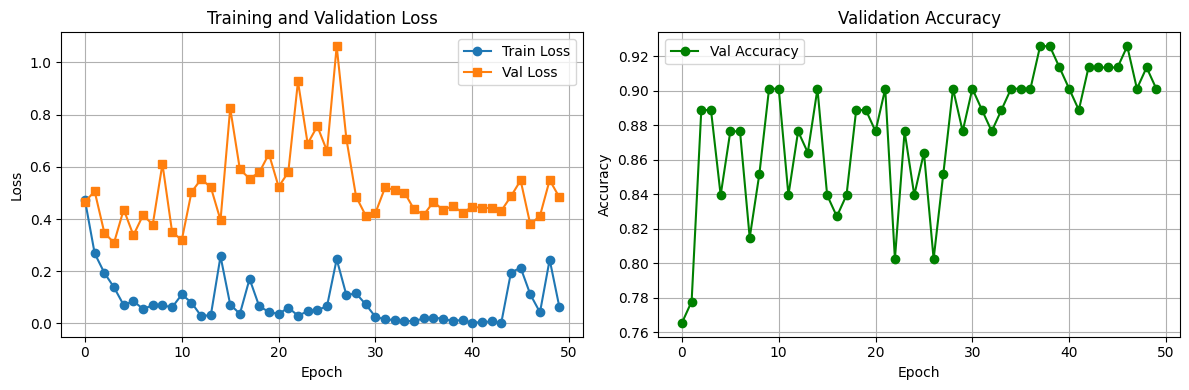

In [107]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_accs, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [108]:
model.load_state_dict(torch.load(best_model_path))
print(f"Loaded best model weights (best_val_acc: {best_val_acc:.4f})")

test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print("\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Loaded best model weights (best_val_acc: 0.9259)

Test Results:
Test Loss: 0.6895
Test Accuracy: 0.8317


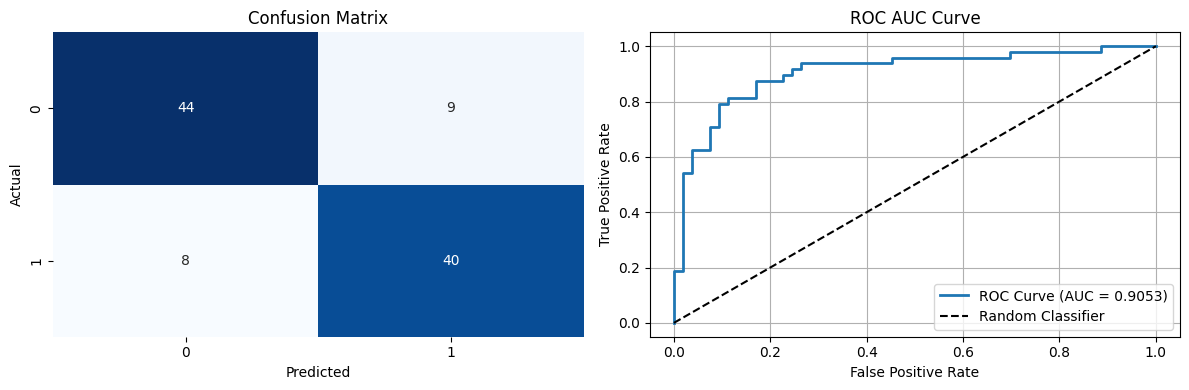


ROC AUC Score: 0.9053


In [109]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

all_preds = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

cm = confusion_matrix(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs[:, 1])
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC AUC Curve')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")



Classification Report:
              precision    recall  f1-score   support

           0     0.8462    0.8302    0.8381        53
           1     0.8163    0.8333    0.8247        48

    accuracy                         0.8317       101
   macro avg     0.8312    0.8318    0.8314       101
weighted avg     0.8320    0.8317    0.8317       101

Per-class metrics:
  Class 0: precision=0.8462  recall=0.8302  f1=0.8381
  Class 1: precision=0.8163  recall=0.8333  f1=0.8247

Macro: precision=0.8312  recall=0.8318  f1=0.8314

Matthews Correlation Coefficient (MCC): 0.6630

Average Precision (AUPRC): 0.9004
Brier score: 0.140243


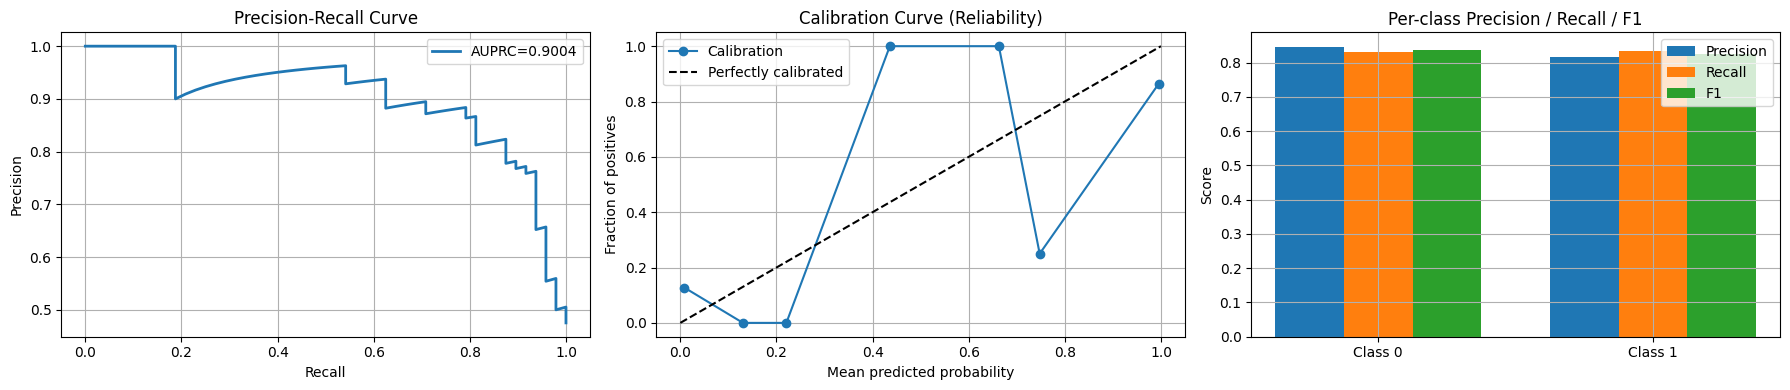

In [ ]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             classification_report, precision_recall_curve,
                             average_precision_score, matthews_corrcoef,
                             brier_score_loss)
from sklearn.calibration import calibration_curve

y_true = all_labels
y_pred = all_preds
y_score = all_probs[:, 1]

prec_per_class = precision_score(y_true, y_pred, average=None)
rec_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

print('\nClassification Report:')
print(classification_report(y_true, y_pred, digits=4))

print('Per-class metrics:')
for i, (p, r, f) in enumerate(zip(prec_per_class, rec_per_class, f1_per_class)):
    print(f'  Class {i}: precision={p:.4f}  recall={r:.4f}  f1={f:.4f}')

prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')
print(f'\nMacro: precision={prec_macro:.4f}  recall={rec_macro:.4f}  f1={f1_macro:.4f}')

mcc = matthews_corrcoef(y_true, y_pred)
print(f'\nMatthews Correlation Coefficient (MCC): {mcc:.4f}')

prec_pr, rec_pr, pr_thresh = precision_recall_curve(y_true, y_score)
auprc = average_precision_score(y_true, y_score)
print(f'\nAverage Precision (AUPRC): {auprc:.4f}')

brier = brier_score_loss(y_true, y_score)
print(f'Brier score: {brier:.6f}')

prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=10)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(rec_pr, prec_pr, label=f'AUPRC={auprc:.4f}', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(prob_pred, prob_true, marker='o', label='Calibration')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction of positives')
axes[1].set_title('Calibration Curve (Reliability)')
axes[1].legend()
axes[1].grid(True)

labels = [f'Class {i}' for i in range(len(prec_per_class))]
x = np.arange(len(labels))
width = 0.25
axes[2].bar(x - width, prec_per_class, width, label='Precision')
axes[2].bar(x, rec_per_class, width, label='Recall')
axes[2].bar(x + width, f1_per_class, width, label='F1')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel('Score')
axes[2].set_title('Per-class Precision / Recall / F1')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
